In [1]:
# Test to load one pickle file
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd

from lameg.laminar import compute_csd
from lameg.viz import plot_csd

In [5]:
filepath = '/home/sgailhard/Documents/laminar_meg/laminar_csd_method/simulations/2_double_dipole/2_consecutive/cluster/sim_2_consec_sources'
filename = 'vx27692_2_consec_sources_tmp_dist25win_size25.pickle'

with open(os.path.join(filepath, filename), 'rb') as f:
    data = pickle.load(f)

In [6]:
data

{'sim_vertex': 27692,
 'n_layers': 11,
 'sim_layers': [(1, 9), (3, 7)],
 'patch_size': 5,
 'err_level': 0,
 'sim_patch_size': 5,
 'n_temp_modes_ebb': 4,
 'n_spatial_modes': 'auto',
 'hann_windowing_ebb': False,
 'snr': -5,
 'dipole_moment': [5, 5],
 'sim_signal': array([[0.20389729, 0.21626517, 0.22912852, 0.24248739, 0.25634015,
         0.27068336, 0.28551171, 0.30081795, 0.3165928 , 0.33282485,
         0.3495006 , 0.3666043 , 0.38411797, 0.40202138, 0.42029201,
         0.43890503, 0.45783336, 0.47704765, 0.49651634, 0.51620567,
         0.53607981, 0.55610088, 0.57622907, 0.59642275, 0.61663856,
         0.63683161, 0.65695557, 0.67696285, 0.69680478, 0.7164318 ,
         0.73579366, 0.7548396 , 0.77351861, 0.79177959, 0.80957165,
         0.82684429, 0.84354765, 0.85963276, 0.87505178, 0.88975818,
         0.90370708, 0.91685536, 0.92916196, 0.94058806, 0.95109732,
         0.96065601, 0.96923323, 0.97680111, 0.98333487, 0.98881304,
         0.99321755, 0.9965338 , 0.99875078, 0.

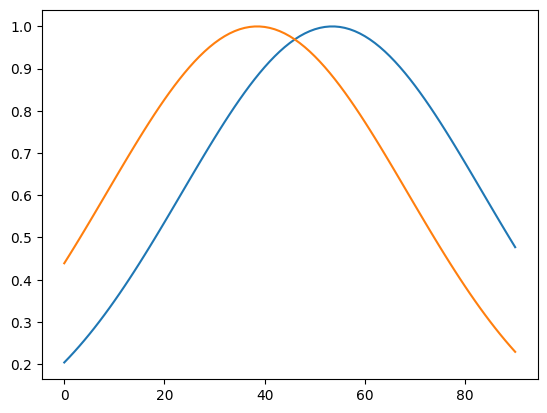

In [8]:
# plot the sim signal
for idx in range(len(data["sim_signal"])):
    plt.plot(data["sim_signal"][idx])

In [9]:
data.keys()

dict_keys(['sim_vertex', 'n_layers', 'sim_layers', 'patch_size', 'err_level', 'sim_patch_size', 'n_temp_modes_ebb', 'n_spatial_modes', 'hann_windowing_ebb', 'snr', 'dipole_moment', 'sim_signal', 'win_size', 'sfreq', 'thickness', 'time', 'ts_ebb_layer', 'ts_slidwd_ebb_layer', 'fs_slidwd', 'fid_coords'])

In [10]:
n_layers = data["n_layers"]

In [12]:
# get the relative free energy 
fs_matrix = data['fs_slidwd']      # (n_rows, 11, 11)
relativeFs = np.array([
        fs_matrix[sim_idx, :] - fs_matrix[sim_idx, :].min()
        for sim_idx in range(fs_matrix.shape[0])
    ])

In [13]:
relativeFs.shape #(n_sim, n_layers)

(2, 11, 91)

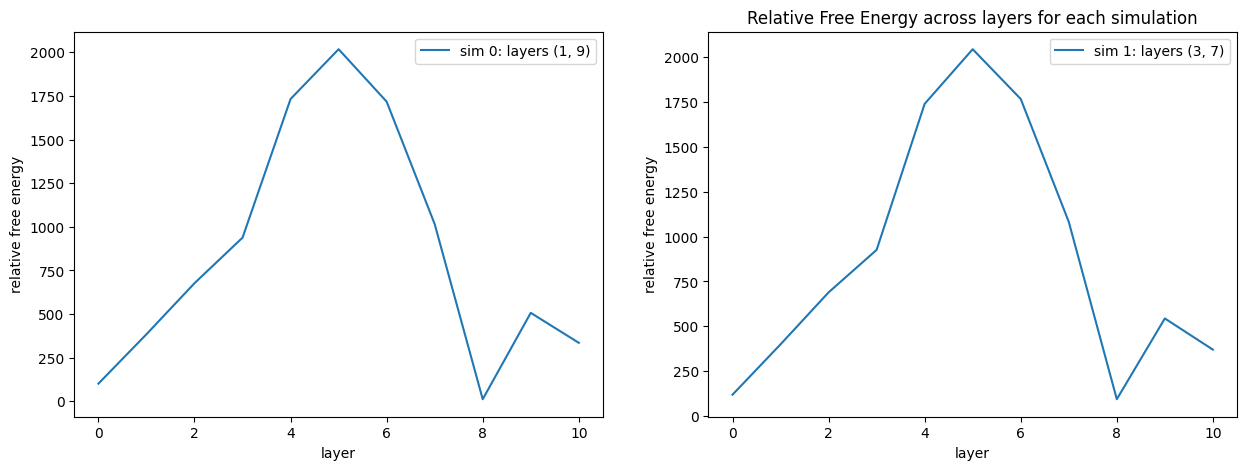

In [15]:
fig, ax = plt.subplots(1, relativeFs.shape[0], figsize=(15, 5))
for i in range(relativeFs.shape[0]):
    ax[i].plot(relativeFs[i, :, 45], label=f'sim {i}: layers {data["sim_layers"][i]}')
    ax[i].set_xlabel('layer')
    ax[i].set_ylabel('relative free energy')
    ax[i].legend()
plt.title('Relative Free Energy across layers for each simulation')
plt.show()

In [16]:
# get the ebb matrix
sfreq = data['sfreq']
thickness = data['thickness']
ebb_matrix = data['ts_ebb_layer']      # (n_sim, n_layers)
csd_ebb = np.array([
        compute_csd(ebb_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 1.333521432163324e-05


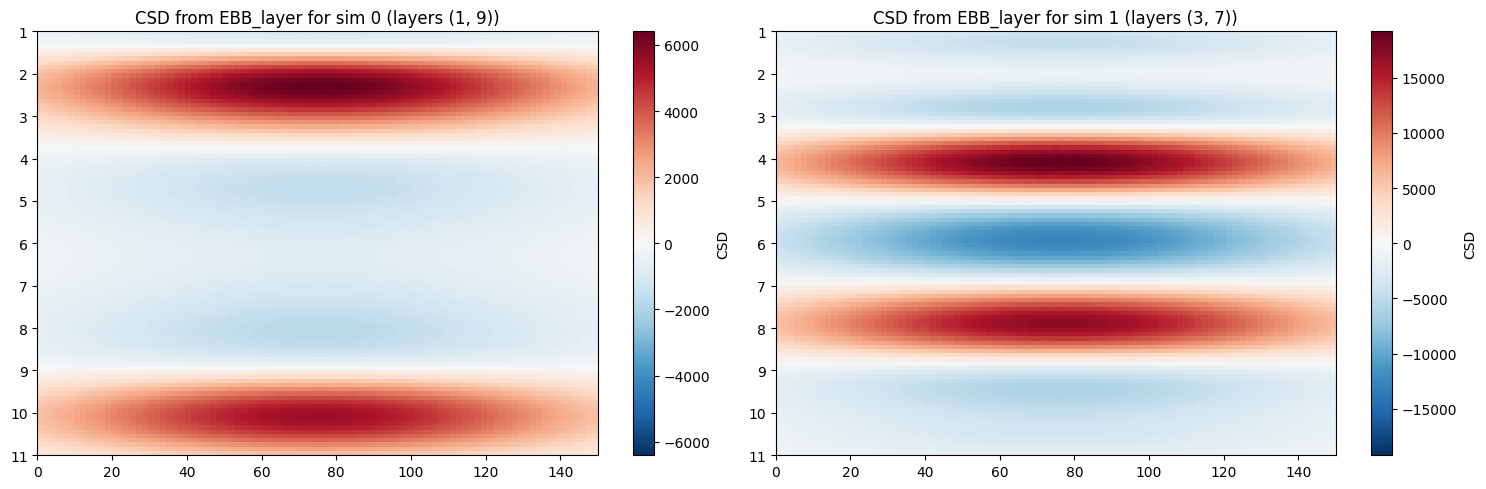

In [20]:
fig, ax = plt.subplots(1, csd_ebb.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb.shape[0]):
    plot_csd(csd_ebb[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')

In [19]:
# get the ebb_layer matrix
ebb_layer_matrix = data['ts_slidwd_ebb_layer']      # (n_sim, n_layers)
csd_ebb_layer = np.array([
        compute_csd(ebb_layer_matrix[sim_idx, :], thickness, sfreq)
        for sim_idx in range(ebb_layer_matrix.shape[0])
    ])

No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.0011006941712522092
No lambda given, using defaults
Cross validating R (all lambda) : 0.23
R, lambda : 0.23 0.01


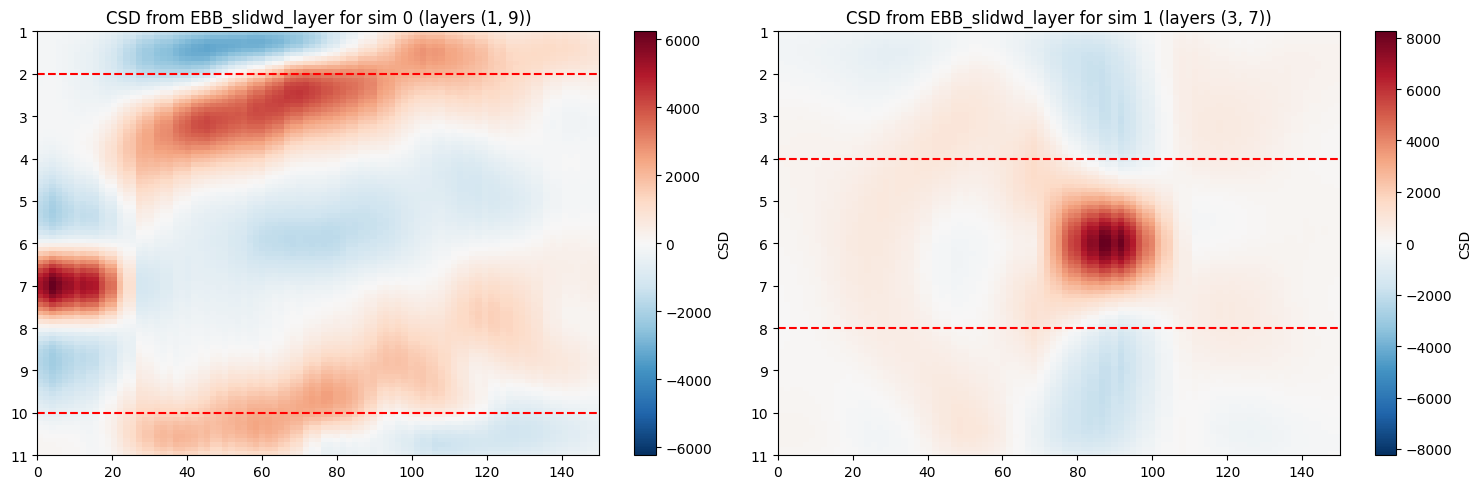

In [21]:
fig, ax = plt.subplots(1, csd_ebb_layer.shape[0], figsize=(15, 5))
for sim_idx in range(csd_ebb_layer.shape[0]):
    plot_csd(csd_ebb_layer[sim_idx, :], data["time"], ax[sim_idx])
    ax[sim_idx].set_title(f'CSD from EBB_slidwd_layer for sim {sim_idx} (layers {data["sim_layers"][sim_idx]})')
    for layer in data["sim_layers"][sim_idx]:
        ax[sim_idx].axhline(layer/(n_layers-1), color='red', linestyle='--')